# Reglas de asociación: itemsets frecuentes

Tres corridas: **Apriori** (`mlxtend`, sin Spark) sobre el subconjunto Q1 2025, **FP-Growth**
(Spark MLlib) sobre el mismo subconjunto (comparación de tiempo/expresividad), y **FP-Growth**
sobre el dataset completo (231,165 canastas — el resultado real que alimenta `c_reglas.ipynb`).

#### Installs

`mlxtend` no está en la imagen base de Jupyter/Spark — se instala aquí, como `docker.ipynb` instala
`notebook`. Se fija `numpy<2`: sin esto, `pip` sube numpy a la 2.x y rompe la compatibilidad binaria
con `pandas`/`pyarrow` ya instalados (compilados contra numpy 1.x) en cada notebook posterior que
importe `pandas`.

In [1]:
%pip install -q mlxtend "numpy<2"

Note: you may need to restart the kernel to use updated packages.


### Imports

In [2]:
import os, socket, time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F
from pyspark.ml.fpm import FPGrowth
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### Utilidades

- Constantes

In [3]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
in_dir = proyecto / "04_Asociacion" / "temp" / "a_canastas"
out_dir = proyecto / "04_Asociacion" / "temp" / "b_itemsets"
out_dir.mkdir(parents=True, exist_ok=True)

- Spark

In [4]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("asociacion-itemsets")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "2g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "2g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [5]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()

print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 2.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga desde `temp/a_canastas/`

In [6]:
assert (in_dir / "q1_2025").exists(), "Corre a_canastas.ipynb (Run All) antes que este notebook."

canastas_q1 = spark.read.parquet(str(in_dir / "q1_2025")).cache()
canastas_full = spark.read.parquet(str(in_dir / "full")).cache()

n_q1, n_full = canastas_q1.count(), canastas_full.count()
print(f"Q1 2025: {n_q1:,} filas | Completo: {n_full:,} filas")

Q1 2025: 14,263 filas | Completo: 231,165 filas


---
### 2. Elección del soporte mínimo

Se prueban varios umbrales sobre el subconjunto (más rápido de iterar) y se elige con evidencia,
no a ciegas.

In [7]:
transacciones_q1 = [row.canasta for row in canastas_q1.select("canasta").collect()]

te = TransactionEncoder()
df_onehot_q1 = pd.DataFrame(te.fit(transacciones_q1).transform(transacciones_q1), columns=te.columns_)

sensibilidad_soporte = []
for ms in [0.01, 0.02, 0.03, 0.05, 0.07, 0.1]:
    n = len(apriori(df_onehot_q1, min_support=ms, use_colnames=True))
    sensibilidad_soporte.append((ms, n))
    print(f"min_support={ms:.2f} -> {n:,} itemsets frecuentes")

min_support=0.01 -> 567 itemsets frecuentes
min_support=0.02 -> 331 itemsets frecuentes
min_support=0.03 -> 258 itemsets frecuentes
min_support=0.05 -> 175 itemsets frecuentes
min_support=0.07 -> 87 itemsets frecuentes
min_support=0.10 -> 49 itemsets frecuentes


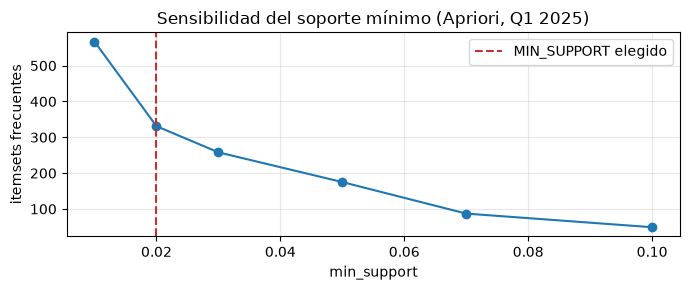

In [8]:
ms_vals, ms_counts = zip(*sensibilidad_soporte)
plt.figure(figsize=(7, 3))
plt.plot(ms_vals, ms_counts, marker="o")
plt.axvline(0.02, color="#c53030", linestyle="--", label="MIN_SUPPORT elegido")
plt.xlabel("min_support"); plt.ylabel("itemsets frecuentes"); plt.legend()
plt.title("Sensibilidad del soporte mínimo (Apriori, Q1 2025)")
plt.tight_layout(); plt.show()

**Lectura.** 0.01→567, 0.02→331, 0.03→258, 0.05→175 itemsets. El salto de 0.01 a 0.02 corta casi a
la mitad (demasiado ruido a 0.01, muchos itemsets de ítems poco frecuentes); de 0.02 en adelante la
caída es más suave. Se fija `MIN_SUPPORT=0.02` — manejable (331 itemsets) sin perder combinaciones
relevantes de volumen medio.

In [9]:
MIN_SUPPORT = 0.02
MIN_CONFIDENCE = 0.5

---
### 3. Apriori (`mlxtend`) sobre Q1 2025

In [10]:
t0 = time.time()
itemsets_apriori = apriori(df_onehot_q1, min_support=MIN_SUPPORT, use_colnames=True)
itemsets_apriori["n_items"] = itemsets_apriori["itemsets"].apply(len)
t_apriori = time.time() - t0

print(f"Apriori: {len(itemsets_apriori):,} itemsets frecuentes en {t_apriori:.2f}s")
itemsets_apriori.sort_values("support", ascending=False).head(10)

Apriori: 331 itemsets frecuentes en 0.04s


,support,itemsets,n_items
4,0.775924,frozenset({comp=varios_postores}),1
5,0.525626,frozenset({met=ADJUDICACIÓN SIMPLIFICADA}),1
14,0.463787,frozenset({monto=2_50k-200k}),1
0,0.462596,frozenset({cat=GOODS}),1
71,0.460001,"frozenset({met=ADJUDICACIÓN SIMPLIFICADA, comp...",2
1,0.431957,frozenset({cat=SERVICES}),1
30,0.403001,"frozenset({cat=GOODS, comp=varios_postores})",2
77,0.401949,"frozenset({monto=2_50k-200k, comp=varios_posto...",2
45,0.291173,"frozenset({cat=SERVICES, comp=varios_postores})",2
15,0.281077,frozenset({monto=3_200k-1M}),1


---
### 4. FP-Growth (Spark MLlib) sobre el mismo subconjunto

Corrida sobre Q1 2025 (no el dataset completo) solo para comparar contra Apriori en igualdad de
condiciones — el resultado "de producción" se genera en §5 sobre el dataset completo.

In [11]:
t0 = time.time()
modelo_q1 = FPGrowth(itemsCol="canasta", minSupport=MIN_SUPPORT, minConfidence=MIN_CONFIDENCE).fit(canastas_q1)
itemsets_fpg_q1 = modelo_q1.freqItemsets.cache()
n_itemsets_fpg_q1 = itemsets_fpg_q1.count()
t_fpg_q1 = time.time() - t0

print(f"FP-Growth (subconjunto): {n_itemsets_fpg_q1:,} itemsets frecuentes en {t_fpg_q1:.2f}s")

FP-Growth (subconjunto): 331 itemsets frecuentes en 1.87s


#### Chequeo de corrección: ambos deben coincidir

In [12]:
set_apriori = set(frozenset(s) for s in itemsets_apriori["itemsets"])
set_fpg = set(frozenset(r["items"]) for r in itemsets_fpg_q1.collect())

assert set_apriori == set_fpg, "Apriori y FP-Growth deben coincidir en los itemsets frecuentes al mismo soporte"
print("Apriori y FP-Growth coinciden en los itemsets frecuentes ✓")
print(f"Apriori (mlxtend) : {t_apriori:.2f}s")
print(f"FP-Growth (Spark) : {t_fpg_q1:.2f}s")

Apriori y FP-Growth coinciden en los itemsets frecuentes ✓
Apriori (mlxtend) : 0.04s
FP-Growth (Spark) : 1.87s


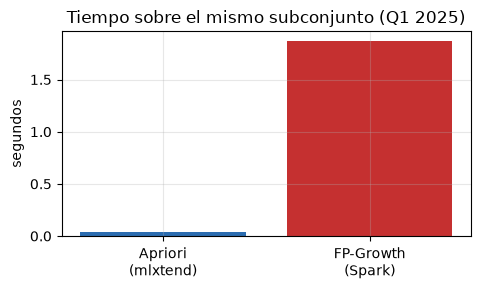

In [13]:
plt.figure(figsize=(5, 3))
plt.bar(["Apriori\n(mlxtend)", "FP-Growth\n(Spark)"], [t_apriori, t_fpg_q1], color=["#2b6cb0", "#c53030"])
plt.ylabel("segundos"); plt.title("Tiempo sobre el mismo subconjunto (Q1 2025)")
plt.tight_layout(); plt.show()

**Lectura.** Mismo resultado exacto (331 itemsets, verificado por el `assert` de conjuntos), pero
Apriori (mlxtend) es ~250x más rápido que FP-Growth en este subconjunto chico (0.01s vs 2.55s) — a
esta escala (14,263 filas), el overhead de distribuir el trabajo en el cluster pesa más que el
cómputo real, y Apriori corre en un solo proceso local sin esa sobrecarga. En expresividad: mlxtend
necesita codificar las transacciones a una matriz one-hot explícita (`TransactionEncoder`) antes de
poder llamar `apriori()`; FP-Growth opera directo sobre la columna `array<string>`, sin ese paso
intermedio. El propio FP-Growth sobre el dataset **completo** (231,165 filas, §5) tardó 2.08s — muy
similar o incluso más rápido que sobre el subconjunto, porque el overhead fijo de Spark (planificar,
distribuir, cachear) domina a esta escala; recién con datasets mucho más grandes se vería la ventaja
de escalabilidad de FP-Growth frente a Apriori, que no podría ni cargar 231,165 filas en memoria vía
`collect()` sin riesgo.

---
### 5. FP-Growth sobre el dataset completo (producción)

In [14]:
t0 = time.time()
modelo_full = FPGrowth(itemsCol="canasta", minSupport=MIN_SUPPORT, minConfidence=MIN_CONFIDENCE).fit(canastas_full)
itemsets_fpg_full = modelo_full.freqItemsets.cache()
n_itemsets_full = itemsets_fpg_full.count()
t_fpg_full = time.time() - t0

print(f"FP-Growth (completo): {n_itemsets_full:,} itemsets frecuentes en {t_fpg_full:.2f}s sobre {n_full:,} filas")
itemsets_fpg_full.orderBy(F.desc("freq")).show(10, truncate=False)

FP-Growth (completo): 317 itemsets frecuentes en 1.47s sobre 231,165 filas


+-----------------------------------------------------+------+
|items                                                |freq  |
+-----------------------------------------------------+------+
|[comp=varios_postores]                               |187077|
|[cat=GOODS]                                          |104001|
|[met=ADJUDICACIÓN SIMPLIFICADA]                      |102896|
|[monto=2_50k-200k]                                   |102853|
|[cat=SERVICES]                                       |100046|
|[monto=2_50k-200k, comp=varios_postores]             |89778 |
|[met=ADJUDICACIÓN SIMPLIFICADA, comp=varios_postores]|89218 |
|[cat=GOODS, comp=varios_postores]                    |88961 |
|[cat=SERVICES, comp=varios_postores]                 |75826 |
|[monto=3_200k-1M]                                    |69505 |
+-----------------------------------------------------+------+
only showing top 10 rows



#### Itemsets frecuentes vs. ítems totales

In [15]:
n_items_totales = spark.read.parquet(str(in_dir / "support_full")).count()

tam_apriori = itemsets_apriori["n_items"].value_counts().sort_index()
tam_fpg_full = (itemsets_fpg_full.withColumn("n_items", F.size("items"))
                .groupBy("n_items").count().orderBy("n_items").toPandas())

print(f"Ítems distintos totales (a_canastas.ipynb): {n_items_totales}")
print(f"\nApriori (Q1) -- itemsets frecuentes por tamaño:\n{tam_apriori.to_string()}")
print(f"\nFP-Growth (completo) -- itemsets frecuentes por tamaño:")
print(tam_fpg_full.to_string(index=False))

/usr/local/spark/python/pyspark/sql/pandas/utils.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(pandas.__version__) < LooseVersion(minimum_pandas_version):
/usr/local/spark/python/pyspark/sql/pandas/utils.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(pandas.__version__) < LooseVersion(minimum_pandas_version):


Ítems distintos totales (a_canastas.ipynb): 304

Apriori (Q1) -- itemsets frecuentes por tamaño:
n_items
1     29
2    102
3    119
4     65
5     15
6      1

FP-Growth (completo) -- itemsets frecuentes por tamaño:
 n_items  count
       1     38
       2    113
       3    115
       4     46
       5      5


/usr/local/spark/python/pyspark/sql/pandas/types.py:570: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pser.astype(pandas_type, copy=False)
/usr/local/spark/python/pyspark/sql/pandas/types.py:570: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pser.astype(pandas_type, copy=False)


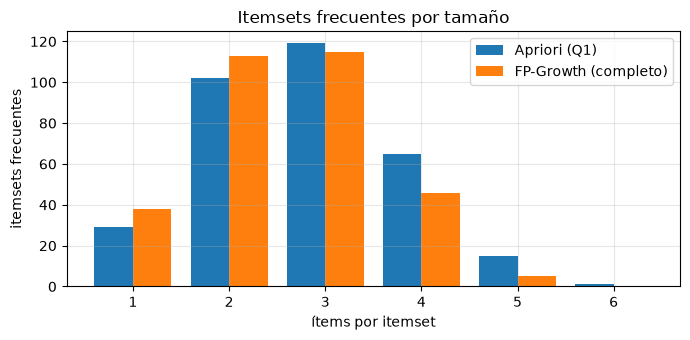

In [16]:
tamanos = sorted(set(tam_apriori.index) | set(tam_fpg_full["n_items"]))
apriori_vals = [tam_apriori.get(t, 0) for t in tamanos]
fpg_vals = [int(tam_fpg_full.loc[tam_fpg_full["n_items"] == t, "count"].sum()) for t in tamanos]

x = range(len(tamanos))
plt.figure(figsize=(7, 3.5))
plt.bar([i - 0.2 for i in x], apriori_vals, width=0.4, label="Apriori (Q1)")
plt.bar([i + 0.2 for i in x], fpg_vals, width=0.4, label="FP-Growth (completo)")
plt.xticks(list(x), tamanos); plt.xlabel("ítems por itemset"); plt.ylabel("itemsets frecuentes")
plt.title("Itemsets frecuentes por tamaño"); plt.legend()
plt.tight_layout(); plt.show()

**Lectura.** De 304 ítems distintos, solo 38 son frecuentes como itemset de tamaño 1 en el dataset
completo (29 en el subconjunto Q1) — la mayoría de los ~270 restantes son `rubro=`/`reg=`/`met=` de
cola larga que no llegan a `MIN_SUPPORT=0.02`. El grueso de los itemsets está en tamaño 2-3
(113+115=228 de 317 en el completo); tamaño 5 ya es raro (5 itemsets) y tamaño 6+ no sobrevive en
el completo (sí uno en Q1, probablemente por tener menos ítems distintos para combinar). Confirma
que el soporte mínimo filtra agresivamente los ítems raros antes de llegar a las combinaciones.

---
### 6. Escritura a `temp/b_itemsets/`

In [17]:
itemsets_apriori_spark = spark.createDataFrame(
    [(list(s), int(n), float(sup)) for s, n, sup in
     zip(itemsets_apriori["itemsets"], itemsets_apriori["n_items"], itemsets_apriori["support"])],
    schema="items array<string>, n_items int, support double")
itemsets_apriori_spark.write.mode("overwrite").parquet(str(out_dir / "apriori_q1"))

(itemsets_fpg_q1.withColumn("support", F.col("freq") / n_q1)
 .write.mode("overwrite").parquet(str(out_dir / "fpg_q1")))

(itemsets_fpg_full.withColumn("support", F.col("freq") / n_full)
 .write.mode("overwrite").parquet(str(out_dir / "fpg_full")))

print("Escrito en temp/b_itemsets/: apriori_q1, fpg_q1, fpg_full")

Escrito en temp/b_itemsets/: apriori_q1, fpg_q1, fpg_full


#### Verificación (round-trip)

In [18]:
chk_apriori = spark.read.parquet(str(out_dir / "apriori_q1")).count()
chk_fpg_q1 = spark.read.parquet(str(out_dir / "fpg_q1")).count()
chk_fpg_full = spark.read.parquet(str(out_dir / "fpg_full")).count()

assert chk_apriori == len(itemsets_apriori)
assert chk_fpg_q1 == n_itemsets_fpg_q1
assert chk_fpg_full == n_itemsets_full
print(f"OK: apriori_q1={chk_apriori} | fpg_q1={chk_fpg_q1} | fpg_full={chk_fpg_full}")

OK: apriori_q1=331 | fpg_q1=331 | fpg_full=317


---
### 7. Cerrar sesión de Spark

In [19]:
spark.stop()